# Homework 8 — Quadratic Discriminant Analysis from Scratch

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

QDA models each class as a multivariate normal distribution with its **own** covariance matrix, and classifies a point by asking which of those distributions makes it most likely. The whole method reduces to a handful of matrix operations — a covariance per class, its inverse, its log-determinant — so it is written here directly in NumPy and then checked against `sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis`.

In [1]:
# Environment setup & imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 85})
RANDOM_STATE = 42

print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.9.1


## Step 1: Load the Iris Dataset

In [2]:
data = load_iris(as_frame=True)

X = data.data.to_numpy()
y = data.target.to_numpy()
feature_names = list(data.feature_names)
class_names = list(data.target_names)

print(f"Features: {X.shape[0]} samples x {X.shape[1]} features")
print(f"Classes: {dict(enumerate(class_names))}")
data.frame.head()

Features: 150 samples x 4 features
Classes: {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 2: Train / Test Split

30% of the data is held out. The split is stratified, which keeps the three classes balanced in both parts — important here, because each class covariance is estimated from its own training rows only, and a class that loses samples would get a noisier estimate.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, test: {X_test.shape}")
print(pd.DataFrame({
    "train": np.bincount(y_train),
    "test": np.bincount(y_test),
}, index=class_names).to_string())

Train: (105, 4), test: (45, 4)
            train  test
setosa         35    15
versicolor     35    15
virginica      35    15


## Steps 3–6: Per-Class Statistics

QDA needs four quantities per class $k$, all estimated from that class's training rows alone:

$$\hat{\mu}_k = \frac{1}{n_k}\sum_{i \in k} x_i, \qquad
\hat{\Sigma}_k = \frac{1}{n_k - \text{ddof}}\sum_{i \in k}(x_i - \hat{\mu}_k)(x_i - \hat{\mu}_k)^{T}, \qquad
\hat{\Sigma}_k^{-1}, \qquad
\hat{\pi}_k = \frac{n_k}{n}$$

Two implementation details are worth stating up front:

- **`ddof`** decides whether the covariance is the maximum-likelihood estimate (divide by $n_k$) or the unbiased one (divide by $n_k - 1$). Both are defensible; which one scikit-learn uses is checked in Step 9 rather than assumed.
- **the log-determinant** is taken with `np.linalg.slogdet` rather than as `log(det(...))`. The determinants here are of order $10^{-6}$, and in higher dimensions they underflow to zero, at which point the logarithm returns $-\infty$. `slogdet` computes the logarithm directly and never forms the tiny number.

In [4]:
def fit_qda(X, y, ddof=0):
    """Estimate mean, covariance, inverse covariance, log-determinant and prior for each class."""
    model = {"classes": np.unique(y), "ddof": ddof}

    for key in ("means", "covariances", "inverses", "log_determinants", "priors"):
        model[key] = {}

    for k in model["classes"]:
        X_class = X[y == k]                                  # step 3: features of one class
        covariance = np.cov(X_class, rowvar=False, ddof=ddof)  # step 4

        model["means"][k] = X_class.mean(axis=0)
        model["covariances"][k] = covariance
        model["inverses"][k] = np.linalg.inv(covariance)      # step 5
        model["log_determinants"][k] = np.linalg.slogdet(covariance)[1]
        model["priors"][k] = len(X_class) / len(X)            # step 6

    return model


qda = fit_qda(X_train, y_train, ddof=0)

summary = pd.DataFrame({
    "n_train": [int((y_train == k).sum()) for k in qda["classes"]],
    "prior": [qda["priors"][k] for k in qda["classes"]],
    "log|cov|": [qda["log_determinants"][k] for k in qda["classes"]],
    "det(cov)": [np.exp(qda["log_determinants"][k]) for k in qda["classes"]],
    "condition number": [np.linalg.cond(qda["covariances"][k]) for k in qda["classes"]],
}, index=class_names)
summary

,n_train,prior,log|cov|,det(cov),condition number
setosa,35,0.333333,-13.706555,0.000001,35.566431
versicolor,35,0.333333,-10.823958,0.000020,37.976045
virginica,35,0.333333,-9.013040,0.000122,25.403940


In [5]:
example = qda["classes"][0]
covariance = pd.DataFrame(qda["covariances"][example], index=feature_names, columns=feature_names)
inverse = pd.DataFrame(qda["inverses"][example], index=feature_names, columns=feature_names)

print(f"Covariance matrix of '{class_names[example]}':")
print(covariance.round(4).to_string())
print(f"\nIts inverse:")
print(inverse.round(2).to_string())

product = qda["covariances"][example] @ qda["inverses"][example]
print(f"\nSigma @ Sigma^-1 equals the identity: {np.allclose(product, np.eye(len(feature_names)))} "
      f"(max deviation {np.abs(product - np.eye(len(feature_names))).max():.2e})")

Covariance matrix of 'setosa':
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)             0.1033            0.1049             0.0087            0.0125
sepal width (cm)              0.1049            0.1739             0.0152            0.0121
petal length (cm)             0.0087            0.0152             0.0229            0.0037
petal width (cm)              0.0125            0.0121             0.0037            0.0093

Its inverse:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
sepal length (cm)              27.25            -15.45               2.77            -17.56
sepal width (cm)              -15.45             15.29              -4.73              2.67
petal length (cm)               2.77             -4.73              48.43            -16.97
petal width (cm)              -17.56              2.67             -16.97            134.97

Sigma @ Sigma^-1 equals the identi

The three determinants differ by two orders of magnitude, which is the whole reason to prefer QDA over LDA here: the classes genuinely have differently shaped and differently sized covariance ellipsoids, and LDA would force a single shared one on all of them.

## Step 7: The Discriminant Function for One Vector

For a multivariate normal the log of the class-conditional density, dropped of the terms that are the same for every class, gives the quadratic discriminant

$$\delta_k(x) = -\frac{1}{2}\log|\hat{\Sigma}_k| - \frac{1}{2}(x - \hat{\mu}_k)^{T}\hat{\Sigma}_k^{-1}(x - \hat{\mu}_k) + \log \hat{\pi}_k$$

The middle term is the squared Mahalanobis distance from $x$ to the class centre, measured in the metric of that class. The name *quadratic* comes from it: since every class has its own $\hat{\Sigma}_k^{-1}$, the $x^{T}\hat{\Sigma}_k^{-1}x$ terms do not cancel when two classes are compared, and the resulting boundary is a quadratic surface rather than a hyperplane.

In [6]:
def discriminant_row(x, model):
    """Values of the quadratic discriminant function for a single observation."""
    scores = []
    for k in model["classes"]:
        centered = x - model["means"][k]
        mahalanobis = centered @ model["inverses"][k] @ centered
        scores.append(-0.5 * model["log_determinants"][k] - 0.5 * mahalanobis + np.log(model["priors"][k]))

    return np.array(scores)


first = X_test[0]
scores = discriminant_row(first, qda)

print(f"Test vector: {dict(zip(feature_names, first))}")
print(f"True class:  {class_names[y_test[0]]}\n")
print(pd.DataFrame({"delta_k": scores}, index=class_names).round(4).to_string())
print(f"\nPredicted: {class_names[qda['classes'][scores.argmax()]]}")

Test vector: {'sepal length (cm)': np.float64(7.3), 'sepal width (cm)': np.float64(2.9), 'petal length (cm)': np.float64(6.3), 'petal width (cm)': np.float64(1.8)}
True class:  virginica

             delta_k
setosa     -663.2101
versicolor   -7.2708
virginica     1.3649

Predicted: virginica


## Step 8: The Whole Test Matrix, and Class Probabilities

The discriminants are computed for every row, and turned into posterior probabilities. Since $\delta_k = \log\left(\hat{\pi}_k \, p_k(x)\right)$ up to a constant that is identical for all classes, Bayes' theorem reduces to a softmax over the $\delta$ values:

$$P(k \mid x) = \frac{e^{\delta_k}}{\sum_j e^{\delta_j}}$$

The maximum is subtracted before exponentiating — a standard trick that changes nothing mathematically (the constant cancels in the ratio) but keeps $e^{\delta}$ from overflowing or underflowing to zero.

In [7]:
def discriminant_matrix(X, model):
    """Discriminant values and posterior probabilities for every row of X."""
    scores = np.vstack([discriminant_row(x, model) for x in X])

    stabilized = np.exp(scores - scores.max(axis=1, keepdims=True))
    probabilities = stabilized / stabilized.sum(axis=1, keepdims=True)

    return scores, probabilities


def predict(X, model):
    scores, _ = discriminant_matrix(X, model)
    return model["classes"][scores.argmax(axis=1)]


scores, probabilities = discriminant_matrix(X_test, qda)
y_pred = predict(X_test, qda)

preview = pd.DataFrame(scores, columns=[f"delta {name}" for name in class_names])
preview = preview.join(pd.DataFrame(probabilities, columns=[f"P({name})" for name in class_names]))
preview.insert(0, "true", [class_names[i] for i in y_test])
preview.head(6).round(4)

,true,delta setosa,delta versicolor,delta virginica,P(setosa),P(versicolor),P(virginica)
0,virginica,-663.2101,-7.2708,1.3649,0.0,0.0002,0.9998
1,versicolor,-293.5366,3.3470,-1.6311,0.0,0.9932,0.0068
2,virginica,-372.2162,1.8244,0.6192,0.0,0.7694,0.2306
3,versicolor,-302.9616,2.1700,-2.6804,0.0,0.9922,0.0078
4,virginica,-361.0451,0.1951,1.8542,0.0,0.1599,0.8401
5,virginica,-576.5366,-16.7193,2.2354,0.0,0.0000,1.0000


In [8]:
matrix = pd.DataFrame(confusion_matrix(y_test, y_pred),
                      index=[f"true {name}" for name in class_names],
                      columns=[f"predicted {name}" for name in class_names])

print(matrix.to_string(), "\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

errors = np.flatnonzero(y_pred != y_test)
for i in errors:
    print(f"Misclassified: true {class_names[y_test[i]]}, predicted {class_names[y_pred[i]]}, "
          f"P = {probabilities[i].round(3)}")

                 predicted setosa  predicted versicolor  predicted virginica
true setosa                    15                     0                    0
true versicolor                 0                    15                    0
true virginica                  0                     1                   14 

Accuracy: 0.9778

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        15
  versicolor     0.9375    1.0000    0.9677        15
   virginica     1.0000    0.9333    0.9655        15

    accuracy                         0.9778        45
   macro avg     0.9792    0.9778    0.9778        45
weighted avg     0.9792    0.9778    0.9778        45

Misclassified: true virginica, predicted versicolor, P = [0.    0.769 0.231]


## Step 9: Comparison with `QuadraticDiscriminantAnalysis`

scikit-learn's `decision_function` returns exactly the same quantity $\delta_k(x)$ that was implemented above, so the two can be compared value by value rather than only through their predictions — a far stricter test.

In [9]:
reference = QuadraticDiscriminantAnalysis(store_covariance=True).fit(X_train, y_train)

reference_scores = reference.decision_function(X_test)
reference_proba = reference.predict_proba(X_test)
reference_pred = reference.predict(X_test)

print(f"Accuracy, own implementation: {accuracy_score(y_test, y_pred):.4f}")
print(f"Accuracy, scikit-learn:       {accuracy_score(y_test, reference_pred):.4f}")
print(f"Identical predictions:        {np.array_equal(y_pred, reference_pred)}\n")
print(f"Largest difference in delta values:  {np.abs(scores - reference_scores).max():.3e}")
print(f"Largest difference in probabilities: {np.abs(probabilities - reference_proba).max():.3e}")
print(f"Largest difference in covariances:   "
      f"{max(np.abs(qda['covariances'][k] - reference.covariance_[i]).max() for i, k in enumerate(qda['classes'])):.3e}")

Accuracy, own implementation: 0.9778
Accuracy, scikit-learn:       0.9778
Identical predictions:        True

Largest difference in delta values:  5.684e-13
Largest difference in probabilities: 8.882e-16
Largest difference in covariances:   2.776e-16


### Which Covariance Estimator Does scikit-learn Use?

The agreement above is not automatic — it depends on the normalization of the covariance matrix. The maximum-likelihood estimator divides by $n_k$, the unbiased one by $n_k - 1$, and scikit-learn has used both across its versions (the current source scales the squared singular values by `n_samples`). Rather than assume, both variants are fitted and compared against the installed version.

In [10]:
comparison = []
for ddof in (0, 1):
    variant = fit_qda(X_train, y_train, ddof=ddof)
    variant_scores, variant_proba = discriminant_matrix(X_test, variant)
    variant_pred = predict(X_test, variant)

    comparison.append({
        "estimator": f"ddof={ddof} ({'maximum likelihood, / n_k' if ddof == 0 else 'unbiased, / (n_k - 1)'})",
        "accuracy": accuracy_score(y_test, variant_pred),
        "same predictions as sklearn": np.array_equal(variant_pred, reference_pred),
        "max |delta - sklearn|": np.abs(variant_scores - reference_scores).max(),
        "max |proba - sklearn|": np.abs(variant_proba - reference_proba).max(),
    })

pd.DataFrame(comparison)

,estimator,accuracy,same predictions as sklearn,max |delta - sklearn|,max |proba - sklearn|
0,"ddof=0 (maximum likelihood, / n_k)",0.977778,True,5.684342e-13,8.881784e-16
1,"ddof=1 (unbiased, / (n_k - 1))",0.977778,True,1.905530e+01,1.008907e-02


The maximum-likelihood variant reproduces scikit-learn to roughly $10^{-13}$ — the level of floating-point round-off — while the unbiased one is off by up to 19 units in $\delta$ and one percentage point in the probabilities. Both still produce **identical predictions**: with 35 training samples in every class the factor $n_k/(n_k-1)$ is the same for all three, so it shifts the discriminants almost in parallel and rarely moves the arg-max. The choice would matter more with unequal or smaller classes.

### What "Quadratic" Looks Like

Fitted on two features, the implementation can be drawn. Beside it is LDA, which pools all classes into one shared covariance matrix and therefore can only produce straight boundaries.

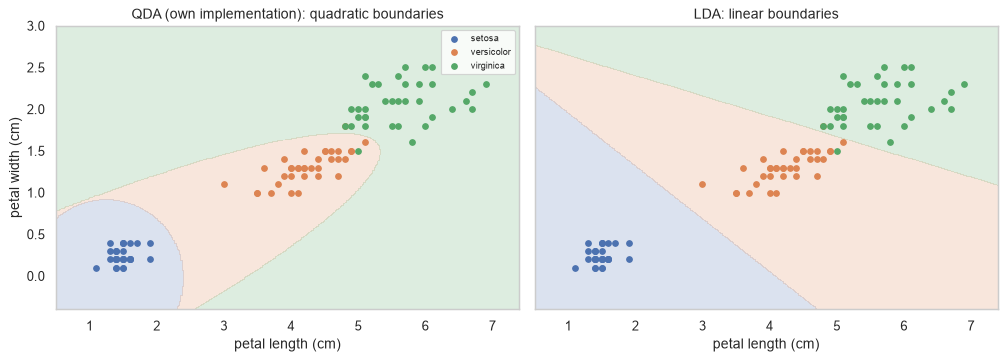

In [11]:
pair = [2, 3]  # petal length, petal width
qda_2d = fit_qda(X_train[:, pair], y_train, ddof=0)
lda_2d = LinearDiscriminantAnalysis().fit(X_train[:, pair], y_train)

x_min, x_max = X[:, pair[0]].min() - 0.5, X[:, pair[0]].max() + 0.5
y_min, y_max = X[:, pair[1]].min() - 0.5, X[:, pair[1]].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, (title, regions) in zip(axes, [
    ("QDA (own implementation): quadratic boundaries", predict(grid, qda_2d).reshape(xx.shape)),
    ("LDA: linear boundaries", lda_2d.predict(grid).reshape(xx.shape)),
]):
    ax.contourf(xx, yy, regions, alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5], colors=sns.color_palette("deep", 3))
    for k, name in enumerate(class_names):
        mask = y_train == k
        ax.scatter(X_train[mask, pair[0]], X_train[mask, pair[1]], s=22, label=name)
    ax.set(title=title, xlabel=feature_names[pair[0]])
    ax.grid(False)

axes[0].set_ylabel(feature_names[pair[1]])
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Conclusion

**The two implementations agree to machine precision.** With the maximum-likelihood covariance the hand-written discriminant values differ from `QuadraticDiscriminantAnalysis.decision_function` by at most $6 \cdot 10^{-13}$ and the posterior probabilities by $9 \cdot 10^{-16}$ — round-off, not disagreement. Predictions are identical and both reach **97.8% accuracy** (44 of 45), the single error being a *virginica* assigned to *versicolor*.

**The agreement hinges on one choice.** Dividing the covariance by $n_k$ instead of $n_k - 1$ is what makes the match exact for this version of scikit-learn; the unbiased estimator shifts $\delta$ by up to 19 units. It does not change the predictions here — equal class sizes make the correction nearly uniform — but it is the kind of detail that makes a from-scratch implementation look wrong when it is merely parameterized differently.

**Two numerical habits earn their place.** `slogdet` avoids forming determinants of order $10^{-6}$ that would underflow in higher dimensions, and subtracting the maximum before the softmax keeps the exponentials in range. Neither changes the mathematics; both decide whether the code survives data less benign than Iris.